In [41]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
RAW_KAONS = '/Volumes/easystore/RAW_Kaon_AnaTree.root'

In [3]:
file = uproot.open(RAW_KAONS)
file.keys()

['anatree;1', 'anatree/raw;143', 'anatree/raw;142']

In [ ]:
tree = file['anatree/raw;143']
tree.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | int32_t                  | AsDtype('>i4')
subrun               | int32_t                  | AsDtype('>i4')
event                | int32_t                  | AsDtype('>i4')
evttime              | double                   | AsDtype('>f8')
rawadc1              | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
rawadc2              | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
rawadc3              | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
rawadc4              | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
rawadc5              | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
rawadc6              | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
rawadc7              | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
rawadc8    

In [38]:
tree.num_entries

3567

In [ ]:
file = RAW_KAONS
tree = uproot.open(file)["anatree/raw;143"]

n = tree.num_entries   

run    = tree["run"].array(library="np")
subrun = tree["subrun"].array(library="np")
event  = tree["event"].array(library="np")

events_df = pd.DataFrame({
    "file_path": [file] * n,
    "event_index": list(range(n)),
    "run": run,
    "subrun": subrun,
    "event": event,
})

events_df

,file_path,event_index,run,subrun,event
0,/Volumes/easystore/RAW_Kaon_AnaTree.root,0,8557,4,456
1,/Volumes/easystore/RAW_Kaon_AnaTree.root,1,8557,38,2007
2,/Volumes/easystore/RAW_Kaon_AnaTree.root,2,8557,44,2258
3,/Volumes/easystore/RAW_Kaon_AnaTree.root,3,8557,52,2623
4,/Volumes/easystore/RAW_Kaon_AnaTree.root,4,8557,71,3445
...,...,...,...,...,...
3562,/Volumes/easystore/RAW_Kaon_AnaTree.root,3562,9788,247,21771
3563,/Volumes/easystore/RAW_Kaon_AnaTree.root,3563,9788,258,22704
3564,/Volumes/easystore/RAW_Kaon_AnaTree.root,3564,9788,267,23425
3565,/Volumes/easystore/RAW_Kaon_AnaTree.root,3565,9788,276,24241


In [99]:
i = 14

data = tree.arrays(
    ["rawadc1", "run", "subrun", "event"],
    entry_start=i,
    entry_stop=i+1,
    library="ak",
)

adc_data = ak.to_numpy(data[0]["rawadc1"])

In [100]:
len(adc_data)

1474560

In [101]:
num_channels_in_event = 480 
num_ticks = len(adc_data) // num_channels_in_event 
num_channels_in_event, num_ticks


adc_data2d = adc_data.reshape((num_channels_in_event, num_ticks)) 

collection = adc_data2d[240:, :]
induction = adc_data2d[:240, :]

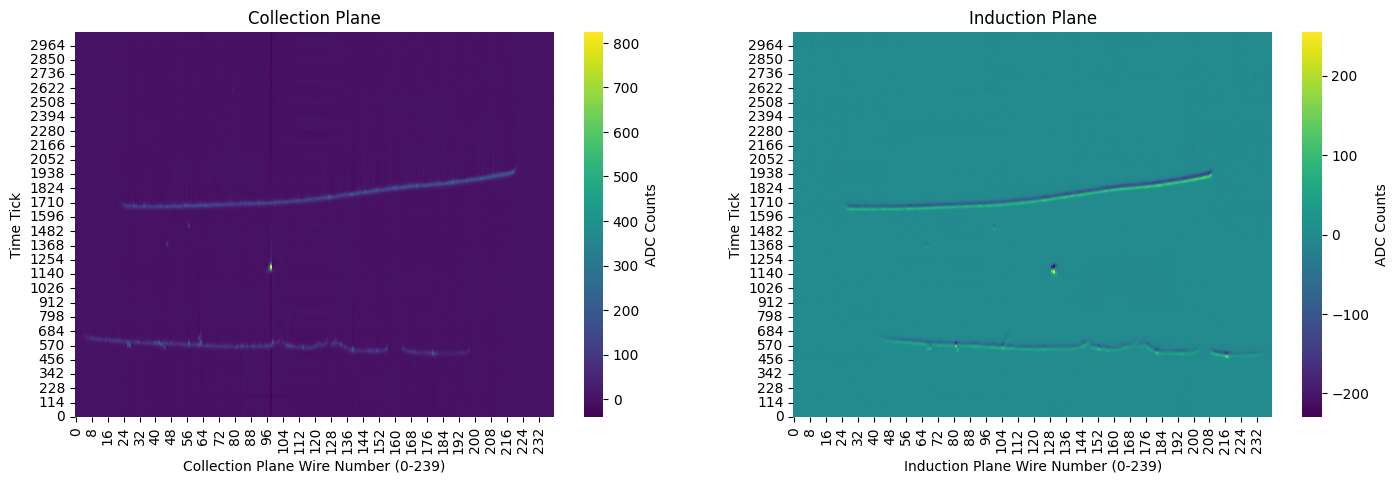

In [102]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))


sns.heatmap(collection.T, cmap="viridis", cbar_kws={'label': 'ADC Counts'}, ax=ax1)
ax1.set_xlabel("Collection Plane Wire Number (0-239)")
ax1.set_ylabel("Time Tick")
ax1.set_title("Collection Plane")
ax1.invert_yaxis()

sns.heatmap(induction.T, cmap='viridis', cbar_kws={'label': 'ADC Counts'}, ax=ax2)
ax2.set_xlabel("Induction Plane Wire Number (0-239)")
ax2.set_ylabel("Time Tick")
ax2.set_title("Induction Plane")
ax2.invert_yaxis()